In [436]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [438]:
X = np.arange(1, 101)
Y = 5 * X + 7 + np.random.uniform(-20, 20, size=100)

In [440]:
def lf(a, b, X, Y):
  return np.sum(((a*X+b)-Y)**2) / (2*len(X))

In [442]:
def cd(X, Y, a, b):
  d1 = np.mean((a * X + b - Y) * X)
  d2 = np.mean(a * X + b - Y)
  return d1, d2

In [444]:
x0 = np.array([0.0, 0.0])
rate = 0.0001
i = 0
a, b = x0[0], x0[1]
t = 0.001
max1 = 100000

In [446]:
d = []
while i < max1:
    d1, d2 = cd(X, Y, a, b)
    a1 = a - rate * d1
    b1 = b - rate * d2
    d.append((d1, d2))
    if np.sqrt((a1 - a)**2 + (b1 - b)**2) <= t:
        break
    a, b = a1, b1
    i += 1
a,b

(5.0940845580782685, 0.0809695458832925)

In [448]:
X_r = X.reshape(-1, 1)
model = LinearRegression()
model.fit(X_r, Y)
a_s = model.coef_[0]
b_s = model.intercept_
a_s, b_s

(4.938749761346668, 10.620805388851466)

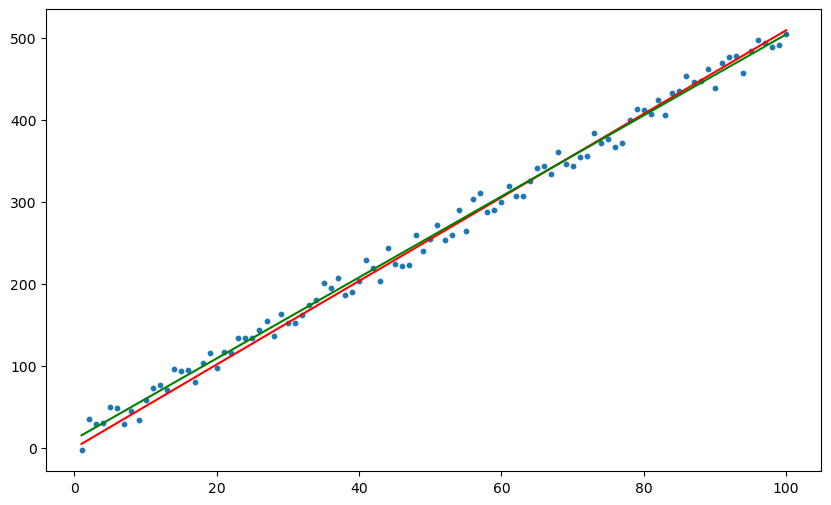

In [450]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, s=10)
y_pred = a * X + b
plt.plot(X, y_pred, color='red')
y_sklearn = a_s * X + b_s
plt.plot(X, y_sklearn, color='green')